# 02 — Vintage curves: the credit analog of a loss development triangle

**This is the centerpiece of the study.**

A vintage curve answers a question a single portfolio-level loss rate cannot:
*is the book getting better or worse?* Group loans by the quarter or year they
were originated, then track cumulative loss against **months on book** — how
long each loan has been alive, not what calendar date it is. Now every cohort is
compared at the same age, and the shape of underwriting change becomes visible.

### If you have built a loss development triangle, you have already built this

| Reserving | Consumer credit |
|---|---|
| Accident year / underwriting year | Origination cohort ("vintage") |
| Development period | Months on book |
| Cumulative paid loss | Cumulative net charge-off |
| Earned premium (the denominator) | Funded principal |
| Ultimate loss ratio | Ultimate cumulative charge-off rate |
| Blank lower-right = future development | Blank lower-right = cohorts too young to have seen it |

It is the same object, and the same instinct reads it: line up the cohorts by
age, look down the column, and ask why one year sits above the others.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src import data_prep as dp  # noqa: E402
from src import plotting as pl  # noqa: E402

pl.set_style()

panel = pd.read_parquet(dp.VINTAGE_PANEL)
print(f"Loaded vintage panel: {len(panel):,} loans, ${panel['funded_amnt'].sum()/1e9:.1f}B funded")

Loaded vintage panel: 2,260,668 loans, $34.0B funded


## Two setup choices, both worth defending

**1. 36-month loans only.** LendingClub writes both 36- and 60-month paper.
Mixing them corrupts the comparison, because a 60-month loan is still amortising
at month 30 while a 36-month loan is nearly done — the two have different loss
timing *by construction*, before any credit difference. Holding term fixed makes
the curves comparable. (The 60-month book is a smaller, structurally riskier
slice; it deserves its own triangle rather than being averaged into this one.)

**2. Dollar-weighted, not loan-count-weighted.** A portfolio loses money, not
loans. Cumulative loss rate is charge-off dollars over funded principal, so a
\\$35,000 default counts for what it actually costs.

In [2]:
panel36 = panel[panel["term_months"] == 36].copy()

# Vintages 2012 onward: before 2012 LendingClub was originating a few thousand
# loans a year under a materially different (and pre-scale) credit policy, so
# those cohorts are noise rather than signal.
panel36 = panel36[panel36["vintage_year"] >= 2012]

cohort_summary = (
    panel36.groupby("vintage_year")
    .agg(
        loans=("funded_amnt", "size"),
        funded_bn=("funded_amnt", lambda s: s.sum() / 1e9),
        observed_mob=("issue_d", lambda s: (dp.SNAPSHOT.year - s.max().year) * 12
                      + (dp.SNAPSHOT.month - s.max().month)),
    )
    .round(2)
)
cohort_summary.columns = ["Loans", "Funded ($B)", "Months observed"]
cohort_summary

,Loans,Funded ($B),Months observed
vintage_year,,,
2012,43470,0.51,75
2013,100422,1.27,63
2014,162570,2.05,51
2015,283173,3.63,39
2016,323495,4.13,27
2017,320419,3.99,15
2018,344671,4.64,3


## The development triangle

Rows are origination cohorts, columns are months on book, cells are cumulative
net charge-off as a percent of that cohort's funded principal.

The blank lower-right is not missing data. It is the future: the 2018 vintage
has been alive for three months, so we do not draw it at month 24. Refusing to
fill those cells is the same discipline as not booking an accident year at
ultimate before it has developed.

In [3]:
triangle = dp.vintage_triangle(panel36, cohort_col="vintage_year", max_mob=36)
display_cols = [c for c in triangle.columns if c % 3 == 0 and c > 0]
tri_display = (triangle[display_cols] * 100).round(2)
tri_display.index.name = "Vintage"
tri_display

months_on_book,3,6,9,12,15,18,21,24,27,30,33,36
Vintage,,,,,,,,,,,,
2012,0.52,1.50,2.62,3.72,4.59,5.34,5.95,6.38,6.68,6.88,6.98,7.02
2013,0.41,1.10,1.99,2.85,3.65,4.35,4.87,5.29,5.56,5.73,5.82,5.85
2014,0.41,1.20,2.12,3.14,4.00,4.73,5.34,5.84,6.17,6.36,6.45,6.48
2015,0.46,1.36,2.50,3.66,4.70,5.57,6.21,6.67,6.96,7.16,7.26,7.30
2016,0.67,1.94,3.39,4.74,5.89,6.80,7.44,7.89,8.18,NaN,NaN,NaN
2017,0.70,1.89,3.18,4.42,5.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018,0.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


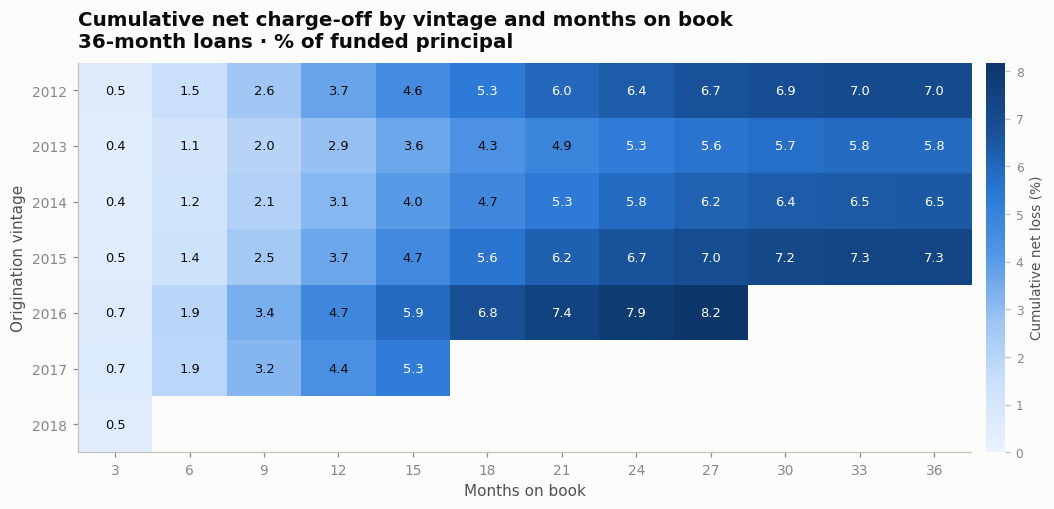

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.6))

data = tri_display.values.astype(float)
im = ax.imshow(data, cmap=pl.SEQ_BLUE, aspect="auto", vmin=0, vmax=np.nanmax(data))

ax.set_xticks(range(len(display_cols)))
ax.set_xticklabels(display_cols)
ax.set_yticks(range(len(tri_display.index)))
ax.set_yticklabels(tri_display.index)
ax.set_xlabel("Months on book")
ax.set_ylabel("Origination vintage")
ax.set_title(
    "Cumulative net charge-off by vintage and months on book\n"
    "36-month loans · % of funded principal",
    loc="left",
)
ax.grid(False)

# Annotate each observed cell. The blank cells stay blank -- that emptiness is
# the most important thing on the chart.
threshold = np.nanmax(data) * 0.62
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data[i, j]
        if np.isnan(v):
            continue
        ax.text(
            j, i, f"{v:.1f}",
            ha="center", va="center", fontsize=8.5,
            color="#ffffff" if v > threshold else pl.INK_PRIMARY,
        )

cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.032)
cbar.set_label("Cumulative net loss (%)", color=pl.INK_SECONDARY, fontsize=9)
cbar.outline.set_visible(False)
cbar.ax.tick_params(color=pl.AXISLINE, labelcolor=pl.INK_MUTED, labelsize=8)

pl.save_fig(fig, "02_development_triangle.png")
plt.show()

## The vintage curves

The same numbers, drawn as curves. Each line is one origination year developing
its losses over time; the ramp runs light (older) to dark (newer), so the
direction of travel is readable without checking the legend.

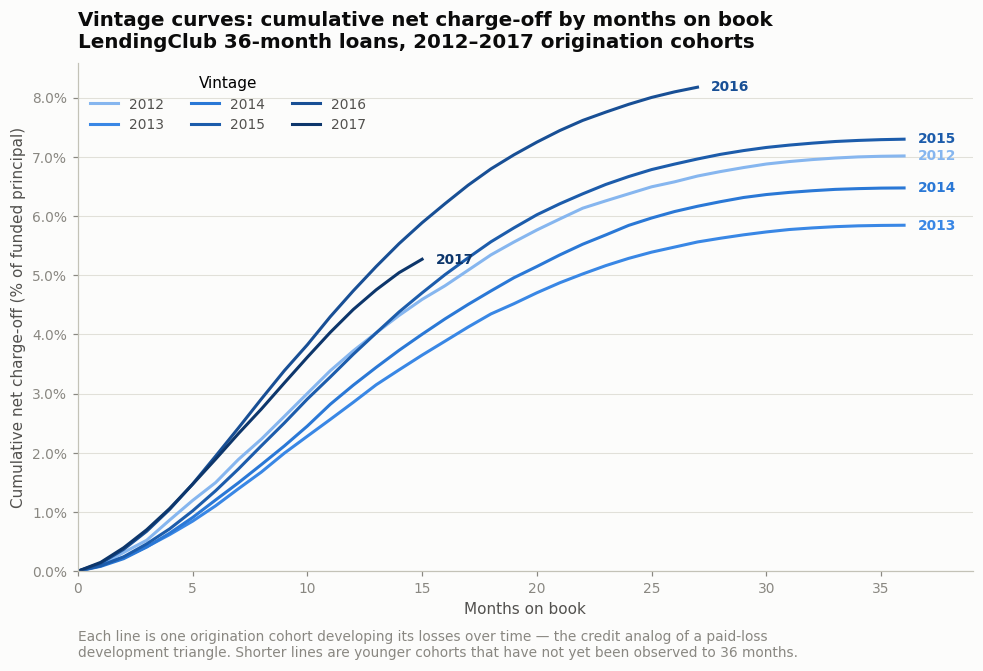

In [5]:
plot_years = [y for y in triangle.index if y <= 2017]
colors = pl.ordinal_colors(len(plot_years))

fig, ax = plt.subplots(figsize=(10.5, 6))

for year, color in zip(plot_years, colors):
    series = triangle.loc[year].dropna()
    ax.plot(series.index, series.values, color=color, label=str(year))
    pl.annotate_last(ax, series.index[-1], series.values[-1], str(year), color)

ax.set_xlabel("Months on book")
ax.set_ylabel("Cumulative net charge-off (% of funded principal)")
ax.set_title(
    "Vintage curves: cumulative net charge-off by months on book\n"
    "LendingClub 36-month loans, 2012–2017 origination cohorts",
    loc="left",
)
ax.set_xlim(0, 39)
ax.set_ylim(0, None)
pl.pct_axis(ax)
pl.style_axes(ax)
ax.legend(title="Vintage", ncol=3, loc="upper left")

fig.text(
    0.125, -0.02,
    "Each line is one origination cohort developing its losses over time — the credit analog of a paid-loss\n"
    "development triangle. Shorter lines are younger cohorts that have not yet been observed to 36 months.",
    fontsize=9, color=pl.INK_MUTED, ha="left",
)

pl.save_fig(fig, "02_vintage_curves.png")
plt.show()

## Reading it: the same-age comparison

The curves are the picture; the *decision* comes from slicing them vertically.
Comparing cohorts at a fixed age strips out the fact that older vintages have
simply had longer to fail, and leaves only the credit difference.

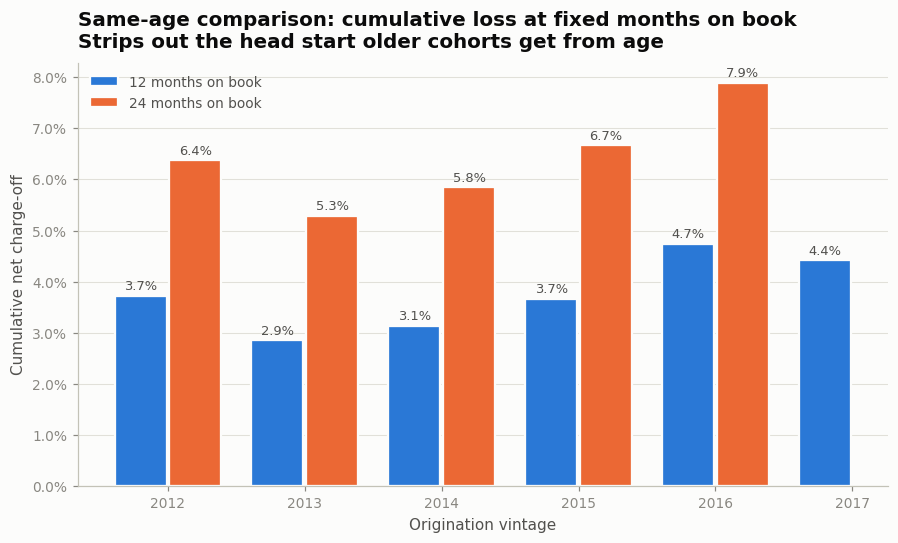

In [6]:
same_age = pd.DataFrame(
    {
        "12 months on book": triangle[12],
        "24 months on book": triangle[24],
    }
).dropna(how="all")

fig, ax = plt.subplots(figsize=(9.5, 5))

x = np.arange(len(same_age))
width = 0.38

for k, (col, color) in enumerate(
    zip(same_age.columns, [pl.CATEGORICAL[0], pl.CATEGORICAL[1]])
):
    vals = same_age[col].values
    bars = ax.bar(
        x + (k - 0.5) * (width + 0.02), vals, width,
        color=color, label=col, edgecolor=pl.SURFACE, linewidth=1.5,
    )
    for xi, v in zip(bars, vals):
        if np.isnan(v):
            continue
        ax.text(
            xi.get_x() + xi.get_width() / 2, v + 0.0012, f"{v*100:.1f}%",
            ha="center", fontsize=8.5, color=pl.INK_SECONDARY,
        )

ax.set_xticks(x)
ax.set_xticklabels(same_age.index)
ax.set_xlabel("Origination vintage")
ax.set_ylabel("Cumulative net charge-off")
ax.set_title(
    "Same-age comparison: cumulative loss at fixed months on book\n"
    "Strips out the head start older cohorts get from age",
    loc="left",
)
pl.pct_axis(ax)
pl.style_axes(ax)
ax.legend(loc="upper left")

pl.save_fig(fig, "02_same_age_comparison.png")
plt.show()

## What the curves actually say

Read the 12-month column down the triangle and the story is not subtle:

In [7]:
readout = pd.DataFrame(
    {
        "Loss @ 12 MOB": triangle[12],
        "Loss @ 24 MOB": triangle[24],
        "Loss @ 36 MOB": triangle[36],
    }
)
readout = (readout * 100).round(2)
readout["vs. prior yr @12"] = (readout["Loss @ 12 MOB"].diff()).round(2)
readout.index.name = "Vintage"
readout

,Loss @ 12 MOB,Loss @ 24 MOB,Loss @ 36 MOB,vs. prior yr @12
Vintage,,,,
2012,3.72,6.38,7.02,NaN
2013,2.85,5.29,5.85,-0.87
2014,3.14,5.84,6.48,0.29
2015,3.66,6.67,7.30,0.52
2016,4.74,7.89,NaN,1.08
2017,4.42,NaN,NaN,-0.32
2018,NaN,NaN,NaN,NaN


**1. 2013 was the best book LendingClub wrote.** It sits lowest at every
development age and finishes near 5.9% cumulative net loss at 36 months.

**2. Credit loosened steadily from 2013 to 2016.** Loss at 12 months on book
climbs from 2.9% (2013) to 3.1% (2014) to 3.7% (2015) to 4.7% (2016). At the
same age, on the same product, later cohorts lost more money — that is the
signature of widening credit standards during a period of rapid origination
growth. Note that funded volume roughly doubled between 2013 and 2015 and
doubled again by 2016. Growth and deterioration arrived together, which is the
usual pattern and the usual warning.

**3. 2016 is the worst cohort on the board.** At 24 months on book it had lost
7.9% of principal — more than the *fully developed* 36-month loss of the 2013
and 2014 vintages. Whatever 2016 underwriting did, it did not hold.

**4. 2017 shows tightening.** Loss at 12 months falls back to 4.4%, the first
year-over-year improvement in the series. The curve is still well above 2013–14,
so this is a correction rather than a return to form — but the direction changed.

### Why this matters more than a headline loss rate

The whole-portfolio net loss rate computed in notebook 01 was ~8%. That single
number blends a 5.9% cohort with a cohort tracking toward 9%+, and it tells you
nothing about which direction the book is moving. The triangle does. This is
precisely why reserving is done by accident year rather than on the aggregate
paid-loss number: **the average hides the trend, and the trend is the decision.**

## A caveat, stated plainly

Charge-offs are dated at the borrower's **last payment**, not the accounting
charge-off date. LendingClub charges off at 120 days past due, so the accounting
event lands roughly four months to the right of where these curves place it.

This is deliberate. Last payment is observable and consistently defined for
every loan in the file, and a constant four-month shift moves all cohorts
equally — so the *comparison between vintages*, which is the entire purpose of
the chart, is unaffected. What it does mean is that the absolute level of these
curves should be read as "loss recognised by month *m* of borrower payment
behaviour," not as a booked charge-off balance.

---
**Next:** `03_segmentation.ipynb` — where within the book that loss is
concentrated, by FICO band and loan grade.